In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def setup_project_dirs():
    folders = ["data", "models", "reports", "notebooks"]
    for folder in folders:
        os.makedirs(folder, exist_ok=True)
    print("✅ Project folders ready.")


In [3]:
data = pd.read_csv(r"C:\Users\hp\Desktop\gk_transferval_ml\data\GK TransferVal Dataset.csv",encoding='latin1')




In [4]:
data.describe()

,Record,market value(million),Age,matches played,goals conceded,Saves,clean sheets
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,22.500000,10.042045,28.795455,17.500000,25.340909,51.636364,4.045455
std,12.845233,9.944772,4.256757,13.957577,19.369051,41.755151,4.120028
min,1.000000,0.200000,21.000000,1.000000,0.000000,0.000000,0.000000
25%,11.750000,1.425000,25.750000,4.750000,8.500000,17.500000,1.000000
50%,22.500000,7.500000,29.000000,13.000000,20.000000,38.000000,2.000000
75%,33.250000,18.000000,31.000000,30.250000,41.750000,87.250000,7.250000
max,44.000000,40.000000,39.000000,38.000000,66.000000,150.000000,13.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Record                 44 non-null     int64  
 1   Player                 44 non-null     object 
 2   market value(million)  44 non-null     float64
 3   Nation                 44 non-null     object 
 4   position               44 non-null     object 
 5   club                   44 non-null     object 
 6   League                 44 non-null     object 
 7   Age                    44 non-null     int64  
 8   matches played         44 non-null     int64  
 9   goals conceded         44 non-null     int64  
 10  Saves                  44 non-null     int64  
 11  clean sheets           44 non-null     int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 4.3+ KB


In [6]:
import os
os.makedirs("data", exist_ok=True)



In [7]:
data.to_csv("data/gk_transferval_cleaned.csv", index=False)


In [8]:
data.isnull().sum()

Record                   0
Player                   0
market value(million)    0
Nation                   0
position                 0
club                     0
League                   0
Age                      0
matches played           0
goals conceded           0
Saves                    0
clean sheets             0
dtype: int64

In [9]:
import os

os.makedirs('../reports', exist_ok=True)


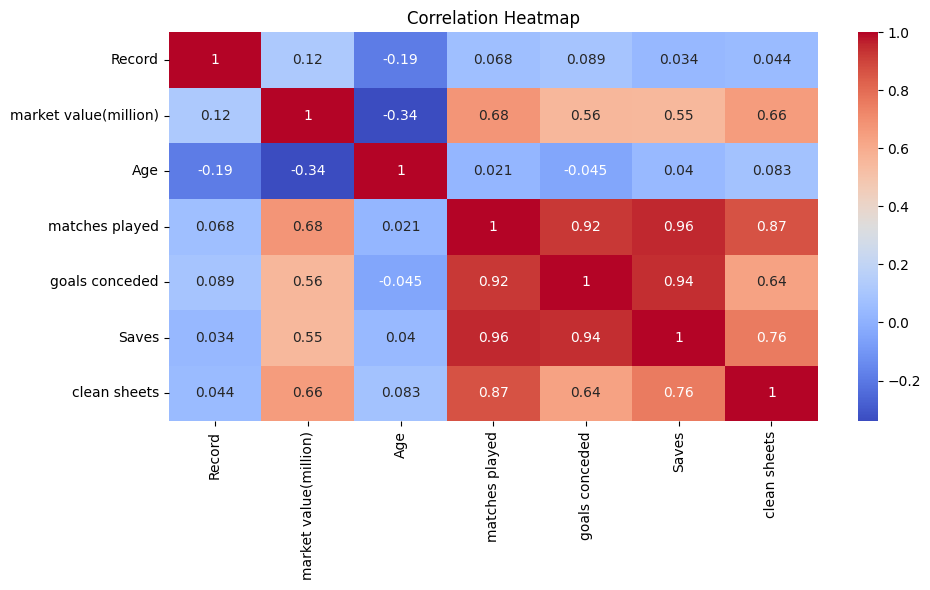

In [10]:

import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

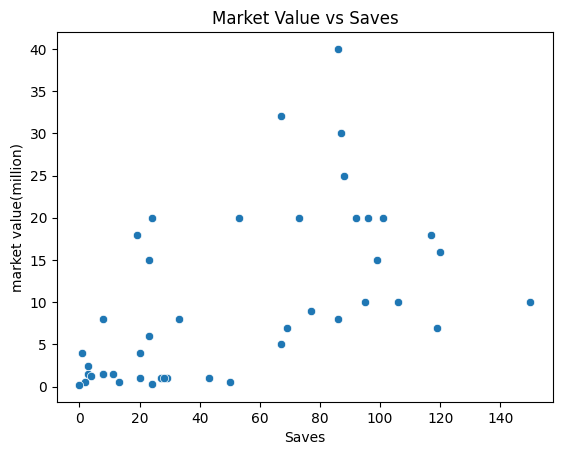

In [11]:
sns.scatterplot(data=data, x='Saves', y='market value(million)')
plt.title("Market Value vs Saves")
plt.savefig('../reports/value_vs_saves.png')
plt.show()

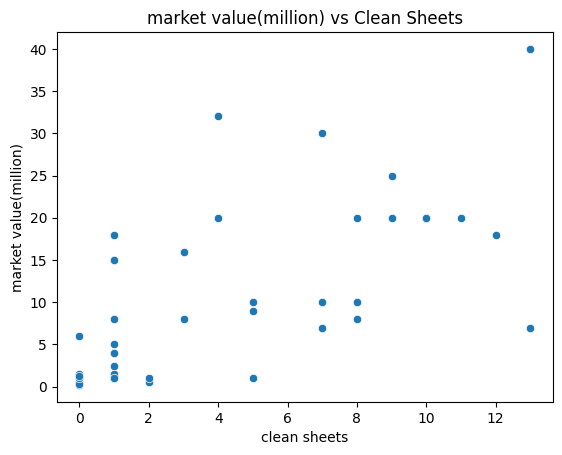

In [12]:
sns.scatterplot(data=data, x='clean sheets', y='market value(million)')
plt.title("market value(million) vs Clean Sheets")
plt.savefig('../reports/value_vs_cleansheets.png')
plt.show()

In [14]:
#LINEAR REGRESSION MODEL

In [15]:
# Step 1: Separate target
y = data['market value(million)']

# Step 2: Drop target from features
X = data.drop(columns=['market value(million)'])

# Step 3: One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)



In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [18]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")



RMSE: 7.00
R² Score: 0.39


In [22]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")


R² Score: 0.39


In [23]:


rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 7.00
R² Score: 0.39


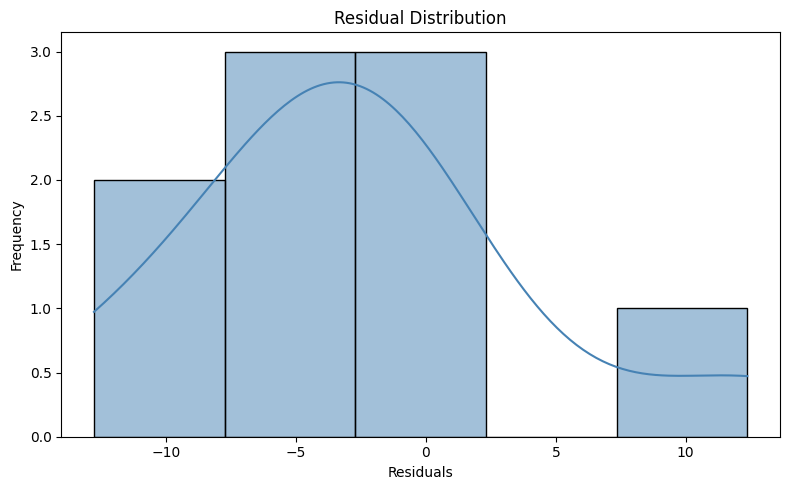

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='steelblue')
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('reports/residual_distribution.png')
plt.show()


In [25]:
import os
os.makedirs("reports", exist_ok=True)


In [26]:
plt.savefig("reports/residual_distribution.png")


<Figure size 640x480 with 0 Axes>

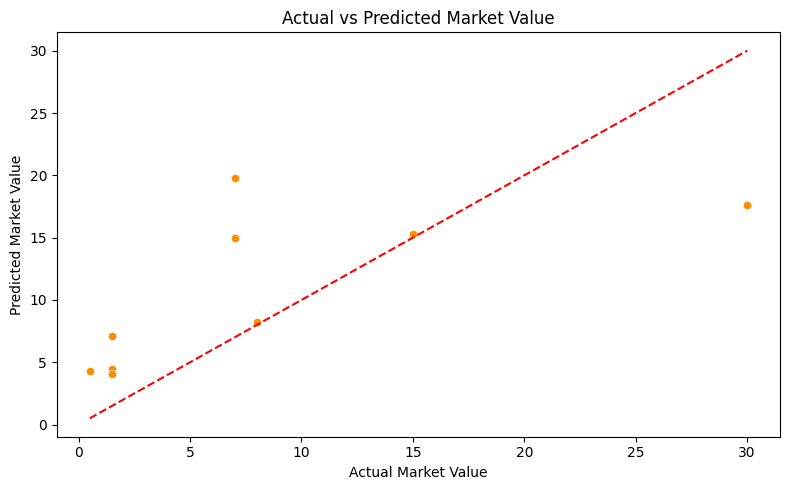

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.xlabel("Actual Market Value")
plt.ylabel("Predicted Market Value")
plt.title("Actual vs Predicted Market Value")
plt.tight_layout()
plt.savefig('reports/actual_vs_predicted.png')
plt.show()


In [28]:
print(len(X.columns))           # Number of feature names
print(len(lr_model.coef_))      # Number of coefficients


88
88


In [29]:
# Step 1: Drop non-feature columns
X_raw = data.drop(columns=["market value(million)", "Player", "Record", "position"])  # Drop ID columns

# Step 2: One-hot encode categorical features
X_encoded = pd.get_dummies(X_raw)

# Step 3: Train-test split
from sklearn.model_selection import train_test_split
y = data["market value(million)"]
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Step 4: Train model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,  
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)


In [31]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coefficients.head(10))  # Top positive influencers
print(coefficients.tail(10))  # Top negative influencers


               Feature  Coefficient
33        club_Everton    14.859785
15          Nation_IRL    11.899248
26        club_Arsenal    11.682800
10          Nation_DEN    11.210487
7           Nation_BRA    10.963997
17          Nation_ITA     9.553890
12          Nation_ESP     9.040790
14          Nation_GER     7.078823
40  club_Newcastle Utd     6.341776
45         club_Wolves     5.701902
                 Feature  Coefficient
13            Nation_FRA    -4.688943
37        club_Liverpool    -5.199421
16            Nation_ISL    -6.248702
11            Nation_ENG   -11.452190
38  club_Manchester City   -11.554599
25            Nation_WAL   -11.586310
28      club_Bournemouth   -13.003429
22            Nation_SVK   -15.475013
34           club_Fulham   -15.684346
20            Nation_POL   -15.860993


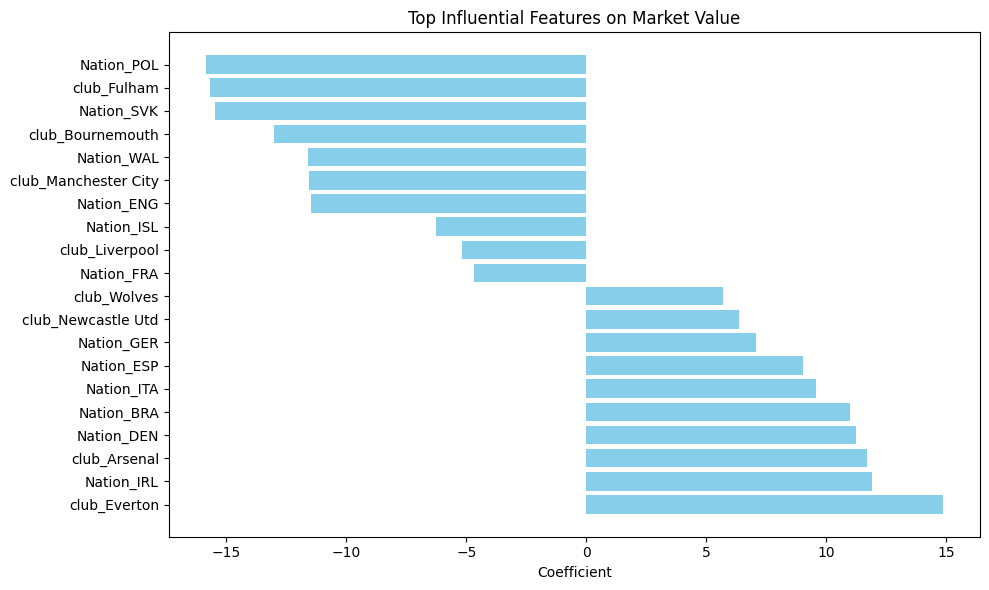

In [32]:
import matplotlib.pyplot as plt

top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])


plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"], color="skyblue")
plt.title("Top Influential Features on Market Value")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.savefig("reports/top_coefficients.png")
plt.show()


In [33]:
new_players = pd.DataFrame([
    {
        "Nation": "England",
        "League": "Premier League",
        "club": "Tottenham",
        "Age": 25,
        "matches played": 12,
        "goals conceded": 18,
        "Saves": 45,
        "clean sheets": 4
    },
    {
        "Nation": "Switzerland",
        "League": "Bundesliga",
        "club": "Dortmund",
        "Age": 26,
        "matches played": 30,
        "goals conceded": 35,
        "Saves": 90,
        "clean sheets": 10
    }
])


In [34]:
# Match training columns
new_encoded = pd.get_dummies(new_players)

# Align with training features
missing_cols = set(X_train.columns) - set(new_encoded.columns)
for col in missing_cols:
    new_encoded[col] = 0  # Add missing columns with 0s

new_encoded = new_encoded[X_train.columns]  # Reorder columns


In [35]:
predicted_values = lr_model.predict(new_encoded)

for name, value in zip(new_players["club"], predicted_values):
    print(f"{name} GK predicted market value: €{value:.2f}M")


Tottenham GK predicted market value: €14.61M
Dortmund GK predicted market value: €15.48M


In [82]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(lr_model, "models/linear_regression_model.pkl")


['models/linear_regression_model.pkl']

In [51]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")


['models/scaler.pkl']